In [1]:
import fast_rv as frv
import numpy as np
import matplotlib.cm
import matplotlib.pyplot as plt
cmap = matplotlib.cm.get_cmap("Spectral")
#%matplotlib widget
#matplotlib.use("TkAgg")
from matplotlib.widgets import RangeSlider
from PyAstronomy.modelSuite import KeplerRVModel
from astroquery.vizier import Vizier
from astropy.timeseries import LombScargle

/tmp/ipykernel_4719/3176628646.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("Spectral")


In [2]:
#This is just an example of how you can use the astropy VizieR interface to find catalogs
#with keywords of your choice
#take the RV data of your choice and copy the ID in the function "name of function" 
vizier = Vizier()
catalogs = vizier.find_catalogs("radial velocity of exoplanets")
for k, v in catalogs.items():
    print(k, ":", v.description)

J/ApJ/727/117 : Radial velocities of four exoplanet candidates (Meschiari+, 2011)
J/ApJ/821/89 : 12yrs of radial velocity obs. of exoplanet systems (Bryan+, 2016)
J/ApJ/888/L5 : Transits, occultation times and RVs of WASP-12b (Yee+, 2020)
J/ApJ/893/L29 : WASP-4 RVs & hot Jupiter predicted period changes (Bouma+, 2020)
J/ApJ/898/L11 : TESS and NGTS LCs and RVs of NGTS-11 (Gill+, 2020)
J/ApJ/899/29 : Radial velocities of TOI-1728 with HPF (Kanodia+, 2020)
J/ApJ/909/115 : Planets Across Space and Time (PAST). I. (Chen+, 2021)
J/ApJ/922/L2 : Limits on binary planets in HR 8799b, c & d (Vanderburg+, 2021)
J/ApJ/926/L8 : Spectroscopic and transit obs. of WASP-148 (Wang+, 2022)
J/ApJ/931/L15 : Obs. of two transits of GJ 3470b with NEID (Stefansson+, 2022)
J/ApJ/944/L41 : In-transit sp. and phot. obs. of TOI-2076b (Frazier+, 2023)
J/ApJ/952/68 : A search for stellar siblings of TOI-251b syst. (Sun+, 2023)
J/ApJS/256/33 : Magellan-TESS Survey (MTS). I. Midsurvey results (Teske+, 2021)
J/ApJS/25

In [3]:
#Use a catalog ID of your choice and inspect the contents of the table
catalog_id = "J/A+A/495/959"
#use these catalog ids if you are lazy to find your own : 
# J/A+A/495/959 
# J/A+A/414/351
# J/A+A/495/959
# J/AJ/151/138
# J/AJ/154/237
# J/AJ/155/107

t = frv.vizier_table_inspection(catalog_id)


Table description: Radial velocity measurements of HD 189733
Total data points: 33
Time : Barycentric Julian Date
RV   : Heliocentric radial velocity
Err  : Error on radial velocity
authors:                                                                                                                                    authors                                                                                                                                   
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Boisse I.; Moutou C.; Vidal-Madjar A.; Bouchy F.; Pont F.; Hebrard G.,Bonfils X.; Croll B.; Delfosse X.; Desort M.; Forveille T.; Lagrange A.-M.,Loeillet B.; Lovis C.; Matthews J.M.; Mayor M.; Pepe F.; Perrier C.,Queloz D.; Rowe J.F.; Santos N.C.; Segransan D.; Udry S.

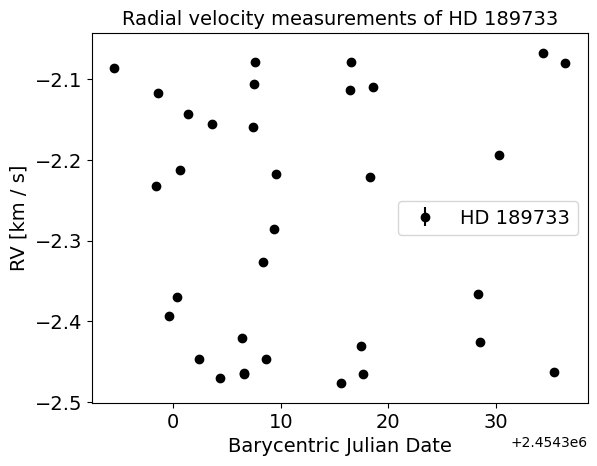

In [4]:
#copy the planet name from above, get the raw data and plot 
name = "HD 189733" 
time_data, rv_data_ms , err_rv_ms = frv.get_vizier_data(catalog_id,name)
plt.show()
                        

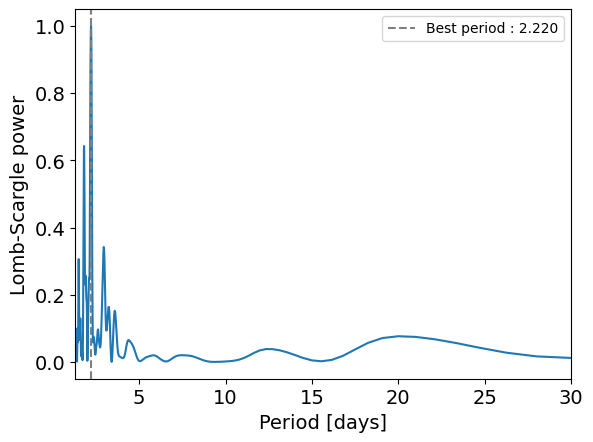

np.float64(2.22010075901645)

In [5]:
#Run a periodogram, which is supposed to give a peak at planet period
# But it is advisable to cross check with NASA EXOPLANET ARCHIVE DATA 
#it runs from period 1.3 to 30.... 
#if you are interested, change from 1 to 15 and see peaks <= 1 day (aliases)  
#else do not change
period_guess = frv.run_periodogram( time_data , rv_data_ms , err_rv_ms , 1.3 , 30)
plt.show()
period_guess


In [6]:
params = {
    "mstar": 0.84,
    "per": period_guess,
    "e": 0.028,
    "w": 136.42,
    "K": 204.7
}
x_data, y_data, y_err, xgrid, ygrid, model = frv.fitting_rv_model(time_data, rv_data_ms, 
                                                              err_rv_ms, **params)
                        

Optimization terminated successfully.
         Current function value: 225.637010
         Iterations: 301
         Function evaluations: 569


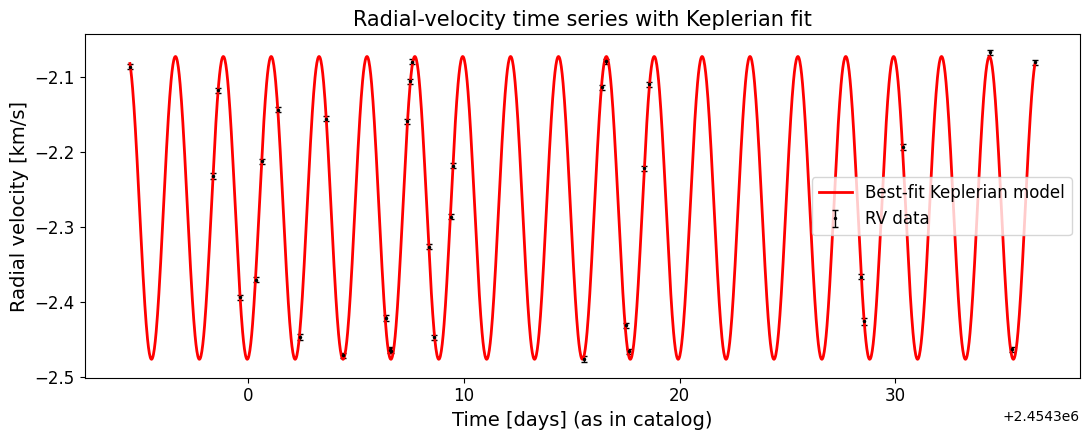

In [7]:
plt.figure(figsize=(11, 4.5))

# data
plt.errorbar(
    x_data, y_data/1e3, yerr=y_err/1e3,
    fmt="k.", ms=3, capsize=2, elinewidth=1,
    label="RV data"
)
# model
plt.plot(xgrid, ygrid/1e3, "r-", lw=2, label="Best-fit Keplerian model")

plt.title("Radial-velocity time series with Keplerian fit", fontsize=15)
plt.xlabel("Time [days] (as in catalog)", fontsize=14)
plt.ylabel("Radial velocity [km/s]", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

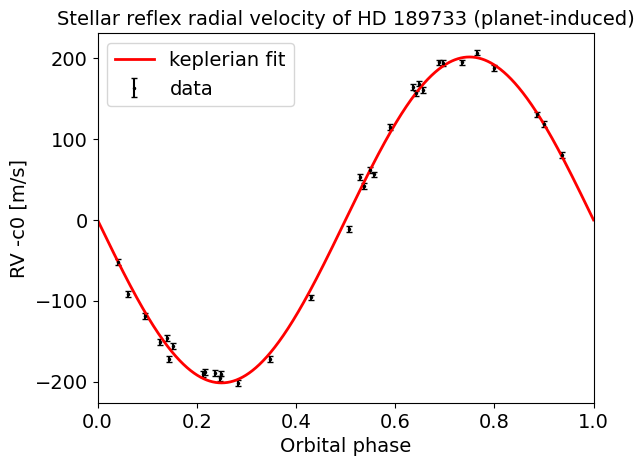

In [8]:
#finally - phase fold it
phase = ((x_data - model["tau1"]) / model["per1"]) % 1.0
idx_p = np.argsort(phase)

phase_grid = np.linspace(0, 1, 2000)
x_phase = model["tau1"] + phase_grid * model["per1"]
y_phase = model.evaluate(x_phase)


plt.errorbar(phase[idx_p], (y_data - model["c0"])[idx_p], yerr=y_err[idx_p],
             fmt="k.", ms=3, capsize=2, label="data")
plt.plot(phase_grid, y_phase - model["c0"], "r-", lw=2, label="keplerian fit")
plt.xlim(0, 1)
plt.xlabel("Orbital phase", fontsize = 14)
plt.ylabel("RV -c0 [m/s]" , fontsize = 14)
plt.title(f"Stellar reflex radial velocity of {name} (planet-induced)",fontsize = 14)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14)
plt.legend( fontsize = 14)
plt.show()